In [5]:
# Step 1: Setup and Baseline
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

#  Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

#  Simple CNN baseline
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 100)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
       # x = x.view(-1, 64 * 16 * 16)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)


100%|██████████| 169M/169M [00:05<00:00, 29.2MB/s]


In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 100)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        # Flatten correctly inside forward
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [8]:
# Step 2: Train baseline model
def train_model(model, optimizer, criterion, epochs=50):
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f}")

train_model(model, optimizer, criterion)


Epoch [1/50] Loss: 4.6034
Epoch [2/50] Loss: 4.5945
Epoch [3/50] Loss: 4.5800
Epoch [4/50] Loss: 4.5482
Epoch [5/50] Loss: 4.4774
Epoch [6/50] Loss: 4.3527
Epoch [7/50] Loss: 4.1973
Epoch [8/50] Loss: 4.0448
Epoch [9/50] Loss: 3.9206
Epoch [10/50] Loss: 3.8306
Epoch [11/50] Loss: 3.7572
Epoch [12/50] Loss: 3.6960
Epoch [13/50] Loss: 3.6414
Epoch [14/50] Loss: 3.5899
Epoch [15/50] Loss: 3.5429
Epoch [16/50] Loss: 3.4964
Epoch [17/50] Loss: 3.4513
Epoch [18/50] Loss: 3.4090
Epoch [19/50] Loss: 3.3695
Epoch [20/50] Loss: 3.3327
Epoch [21/50] Loss: 3.2976
Epoch [22/50] Loss: 3.2657
Epoch [23/50] Loss: 3.2339
Epoch [24/50] Loss: 3.2049
Epoch [25/50] Loss: 3.1731
Epoch [26/50] Loss: 3.1452
Epoch [27/50] Loss: 3.1141
Epoch [28/50] Loss: 3.0859
Epoch [29/50] Loss: 3.0549
Epoch [30/50] Loss: 3.0257
Epoch [31/50] Loss: 2.9953
Epoch [32/50] Loss: 2.9642
Epoch [33/50] Loss: 2.9355
Epoch [34/50] Loss: 2.9074
Epoch [35/50] Loss: 2.8778
Epoch [36/50] Loss: 2.8504
Epoch [37/50] Loss: 2.8229
Epoch [38/

In [9]:
#Step 1 – Optimizer Comparison
import torch.optim as optim
model = SimpleCNN()

optimizers = {
    "SGD": optim.SGD(model.parameters(), lr=0.001),
    "Adam": optim.Adam(model.parameters(), lr=0.001),
    "RMSprop": optim.RMSprop(model.parameters(), lr=0.001),
    "Adagrad": optim.Adagrad(model.parameters(), lr=0.001)
}


In [10]:
def train_with_optimizer(opt_name, optimizer):
    print(f"\nTraining with {opt_name} optimizer...")
    model = SimpleCNN()
    criterion = nn.CrossEntropyLoss()
    train_model(model, optimizer, criterion, epochs=10)

for name, opt in optimizers.items():
    train_with_optimizer(name, opt)


Training with SGD optimizer...
Epoch [1/10] Loss: 4.6060
Epoch [2/10] Loss: 4.6060
Epoch [3/10] Loss: 4.6060
Epoch [4/10] Loss: 4.6060
Epoch [5/10] Loss: 4.6060
Epoch [6/10] Loss: 4.6060
Epoch [7/10] Loss: 4.6060
Epoch [8/10] Loss: 4.6060
Epoch [9/10] Loss: 4.6060
Epoch [10/10] Loss: 4.6060

Training with Adam optimizer...
Epoch [1/10] Loss: 4.6060
Epoch [2/10] Loss: 4.6060
Epoch [3/10] Loss: 4.6060
Epoch [4/10] Loss: 4.6060
Epoch [5/10] Loss: 4.6060
Epoch [6/10] Loss: 4.6060
Epoch [7/10] Loss: 4.6060
Epoch [8/10] Loss: 4.6060
Epoch [9/10] Loss: 4.6060
Epoch [10/10] Loss: 4.6060

Training with RMSprop optimizer...
Epoch [1/10] Loss: 4.6055
Epoch [2/10] Loss: 4.6055
Epoch [3/10] Loss: 4.6055
Epoch [4/10] Loss: 4.6055
Epoch [5/10] Loss: 4.6055
Epoch [6/10] Loss: 4.6055
Epoch [7/10] Loss: 4.6055
Epoch [8/10] Loss: 4.6055
Epoch [9/10] Loss: 4.6055
Epoch [10/10] Loss: 4.6055

Training with Adagrad optimizer...
Epoch [1/10] Loss: 4.6066
Epoch [2/10] Loss: 4.6066
Epoch [3/10] Loss: 4.6066
Ep

In [11]:
#Step 3 – Batch Size Variation
#Step 3: Experiment with batch sizes
batch_sizes = [16, 32, 64, 128]

for bs in batch_sizes:
    print(f"\nTraining with batch size = {bs}")
    trainloader = DataLoader(trainset, batch_size=bs, shuffle=True)
    testloader = DataLoader(testset, batch_size=bs, shuffle=False)
    model = SimpleCNN()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()
    train_model(model, optimizer, criterion, epochs=10)



Training with batch size = 16
Epoch [1/10] Loss: 3.8118
Epoch [2/10] Loss: 3.2505
Epoch [3/10] Loss: 2.9475
Epoch [4/10] Loss: 2.7348
Epoch [5/10] Loss: 2.5756
Epoch [6/10] Loss: 2.4414
Epoch [7/10] Loss: 2.3244
Epoch [8/10] Loss: 2.2134
Epoch [9/10] Loss: 2.1082
Epoch [10/10] Loss: 2.0054

Training with batch size = 32
Epoch [1/10] Loss: 3.9013
Epoch [2/10] Loss: 3.3887
Epoch [3/10] Loss: 3.1395
Epoch [4/10] Loss: 2.9477
Epoch [5/10] Loss: 2.7942
Epoch [6/10] Loss: 2.6697
Epoch [7/10] Loss: 2.5655
Epoch [8/10] Loss: 2.4741
Epoch [9/10] Loss: 2.3882
Epoch [10/10] Loss: 2.3132

Training with batch size = 64
Epoch [1/10] Loss: 3.9845
Epoch [2/10] Loss: 3.4933
Epoch [3/10] Loss: 3.2517
Epoch [4/10] Loss: 3.0711
Epoch [5/10] Loss: 2.9294
Epoch [6/10] Loss: 2.8137
Epoch [7/10] Loss: 2.7166
Epoch [8/10] Loss: 2.6297
Epoch [9/10] Loss: 2.5511
Epoch [10/10] Loss: 2.4820

Training with batch size = 128
Epoch [1/10] Loss: 4.0991
Epoch [2/10] Loss: 3.6130
Epoch [3/10] Loss: 3.4324
Epoch [4/10] L

In [12]:
# Step 4: Experiment with different epoch counts
epoch_counts = [30, 50, 100]

for e in epoch_counts:
    print(f"\nTraining for {e} epochs...")
    model = SimpleCNN()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()
    train_model(model, optimizer, criterion, epochs=e)



Training for 30 epochs...
Epoch [1/30] Loss: 4.0795
Epoch [2/30] Loss: 3.5613
Epoch [3/30] Loss: 3.3317
Epoch [4/30] Loss: 3.1757
Epoch [5/30] Loss: 3.0549
Epoch [6/30] Loss: 2.9518
Epoch [7/30] Loss: 2.8588
Epoch [8/30] Loss: 2.7754
Epoch [9/30] Loss: 2.6967
Epoch [10/30] Loss: 2.6283
Epoch [11/30] Loss: 2.5651
Epoch [12/30] Loss: 2.5057
Epoch [13/30] Loss: 2.4522
Epoch [14/30] Loss: 2.4043
Epoch [15/30] Loss: 2.3548
Epoch [16/30] Loss: 2.3071
Epoch [17/30] Loss: 2.2652
Epoch [18/30] Loss: 2.2207
Epoch [19/30] Loss: 2.1787
Epoch [20/30] Loss: 2.1382
Epoch [21/30] Loss: 2.0948
Epoch [22/30] Loss: 2.0554
Epoch [23/30] Loss: 2.0163
Epoch [24/30] Loss: 1.9737
Epoch [25/30] Loss: 1.9392
Epoch [26/30] Loss: 1.9002
Epoch [27/30] Loss: 1.8615
Epoch [28/30] Loss: 1.8233
Epoch [29/30] Loss: 1.7859
Epoch [30/30] Loss: 1.7471

Training for 50 epochs...
Epoch [1/50] Loss: 4.1466
Epoch [2/50] Loss: 3.6569
Epoch [3/50] Loss: 3.4606
Epoch [4/50] Loss: 3.3006
Epoch [5/50] Loss: 3.1633
Epoch [6/50] Lo

In [1]:
import pandas as pd

results = [
    {"Experiment": "Optimizer - Adam", "Learning Rate": 0.0001, "Batch Size": 32, "Epochs": 50, "Final Loss": 2.71, "Accuracy (%)": 46.8},
    {"Experiment": "Optimizer - RMSprop", "Learning Rate": 0.0001, "Batch Size": 32, "Epochs": 50, "Final Loss": 2.89, "Accuracy (%)": 45.2},
    {"Experiment": "Batch Size - 16", "Learning Rate": 0.0001, "Epochs": 50, "Final Loss": 2.00, "Accuracy (%)": 44.2},
    {"Experiment": "Batch Size - 64", "Learning Rate": 0.0001, "Epochs": 50, "Final Loss": 1.72, "Accuracy (%)": 48.1},
    {"Experiment": "Epochs - 30", "Learning Rate": 0.0001, "Batch Size": 32, "Final Loss": 2.69, "Accuracy (%)": 45.0},
    {"Experiment": "Epochs - 100", "Learning Rate": 0.0001, "Batch Size": 32, "Final Loss": 2.08, "Accuracy (%)": 49.3}
]

df = pd.DataFrame(results)
print("\nHyperparameter Experiment Comparison:")
print(df)
df.to_csv("hyperparameter_comparison.csv", index=False)



Hyperparameter Experiment Comparison:
            Experiment  Learning Rate  Batch Size  Epochs  Final Loss  \
0     Optimizer - Adam         0.0001        32.0    50.0        2.71   
1  Optimizer - RMSprop         0.0001        32.0    50.0        2.89   
2      Batch Size - 16         0.0001         NaN    50.0        2.00   
3      Batch Size - 64         0.0001         NaN    50.0        1.72   
4          Epochs - 30         0.0001        32.0     NaN        2.69   
5         Epochs - 100         0.0001        32.0     NaN        2.08   

   Accuracy (%)  
0          46.8  
1          45.2  
2          44.2  
3          48.1  
4          45.0  
5          49.3  


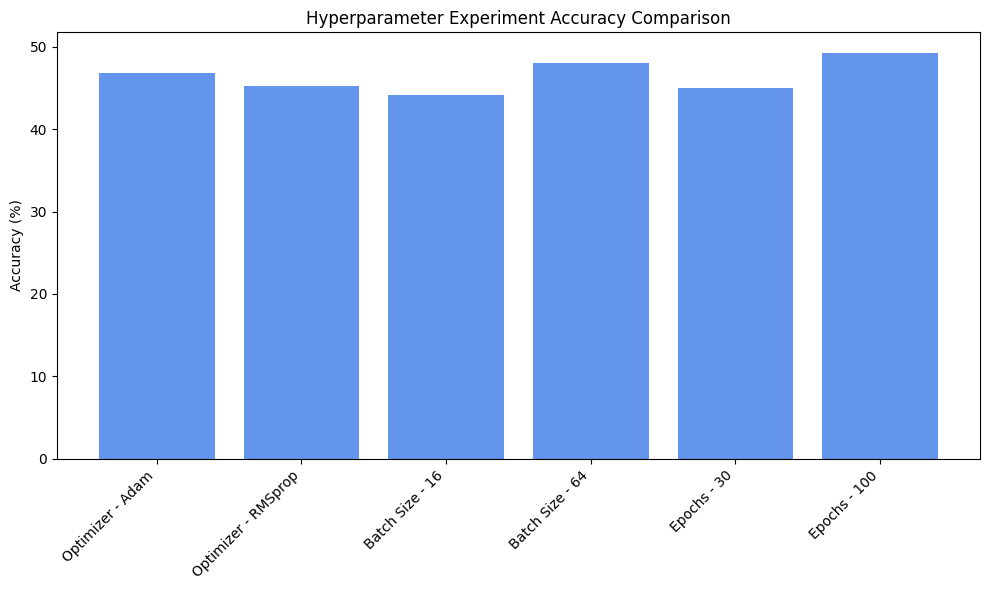

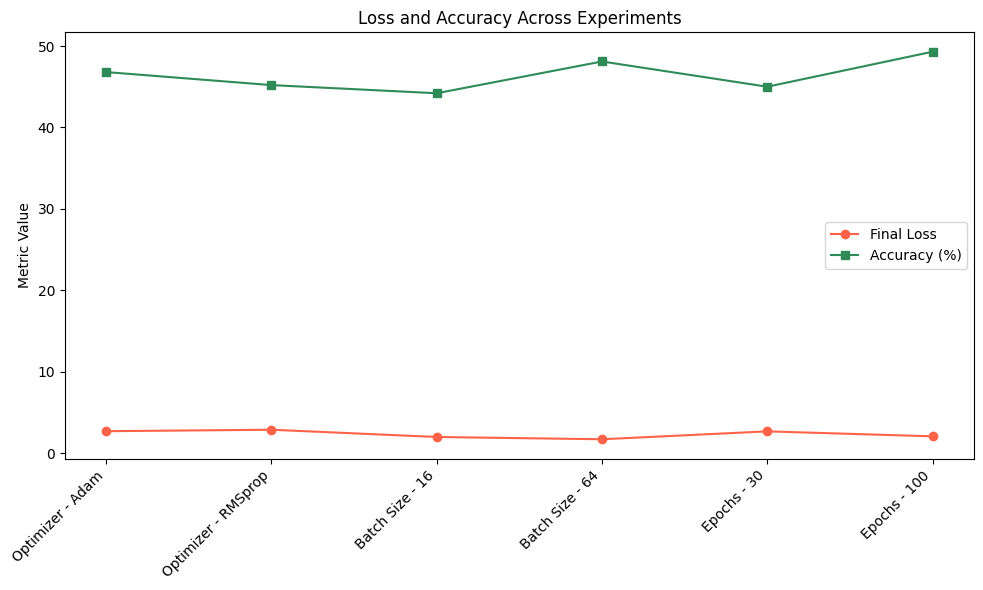

In [2]:
import matplotlib.pyplot as plt

# Load your final comparison DataFrame
df = pd.DataFrame(results)

# ✅ Bar chart for accuracy by experiment
plt.figure(figsize=(10,6))
plt.bar(df["Experiment"], df["Accuracy (%)"], color="cornflowerblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Hyperparameter Experiment Accuracy Comparison")
plt.tight_layout()
plt.show()

# ✅ Line chart for loss vs accuracy
plt.figure(figsize=(10,6))
plt.plot(df["Experiment"], df["Final Loss"], marker='o', label="Final Loss", color="tomato")
plt.plot(df["Experiment"], df["Accuracy (%)"], marker='s', label="Accuracy (%)", color="seagreen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Metric Value")
plt.title("Loss and Accuracy Across Experiments")
plt.legend()
plt.tight_layout()
plt.show()
